In [1]:
"""
Download the full English MultiEURLEX dataset and save it to the Data folder.
"""

import json
import tarfile
from pathlib import Path
from huggingface_hub import hf_hub_download
from tqdm import tqdm

# Configuration
TAR_SPLIT_FILES = {"train.jsonl": "train.jsonl"}
LABEL_LEVEL = "level_1"
HF_TOKEN = "REDACTED"

def main():
    data_dir = Path("Data")
    data_dir.mkdir(exist_ok=True, parents=True)

    # Use existing data if already downloaded
    out_path = data_dir / "train.jsonl"
    if out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            count = sum(1 for _ in f)
        print(f"Data already exists at {out_path}. Using existing file ({count} documents).")
        return

    print("Downloading MultiEURLEX archive from Hugging Face...")
    tar_path = hf_hub_download(
        repo_id="coastalcph/multi_eurlex",
        filename="data/multi_eurlex.tar.gz",
        repo_type="dataset",
        token=HF_TOKEN
    )

    summary = {}
    with tarfile.open(tar_path, "r:gz") as tar:
        for member in tar.getmembers():
            base_name = member.name.split("/")[-1]
            if base_name not in TAR_SPLIT_FILES:
                continue

            print(f"Extracting all English documents in {base_name} ...")
            f = tar.extractfile(member)
            if f is None: continue

            all_lines = f.readlines()
            out_path = data_dir / TAR_SPLIT_FILES[base_name]
            count = 0

            # Write *all* valid English documents
            with open(out_path, "w", encoding="utf-8") as out_f:
                pbar = tqdm(desc=f"Writing {base_name}", total=None, unit=" docs")
                for line in all_lines:
                    data = json.loads(line.decode("utf-8"))
                    if isinstance(data.get("text"), dict) and "en" in data["text"]:
                        record = {
                            "celex_id": data.get("celex_id", ""),
                            "text": data["text"]["en"],
                            "labels": data.get("eurovoc_concepts", {}).get(LABEL_LEVEL, data.get("labels", [])),
                        }
                        out_f.write(json.dumps(record, ensure_ascii=False) + "\n")
                        count += 1
                        pbar.update(1)
                pbar.close()

            summary[base_name.replace(".jsonl", "")] = count
            print(f"  {out_path.name}: {count} English documents saved.")

    summary_meta = {
        "dataset": "coastalcph/multi_eurlex",
        "language": "en",
        "label_level": LABEL_LEVEL,
        "splits": summary,
    }
    with open(data_dir / "dataset_info.json", "w", encoding="utf-8") as f:
        json.dump(summary_meta, f, indent=2)

    print("Extraction of full English set complete.")

if __name__ == "__main__":
    main()

Data already exists at Data/train.jsonl. Using existing file (55000 documents).


Run the notebook from the project root (`TFM/`) so `Data/train.jsonl` resolves correctly.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("Data")
with open(DATA_DIR / "categories.json", encoding="utf-8") as f:
    categories = json.load(f)

df = pd.read_json(DATA_DIR / "train.jsonl", lines=True)
df.shape

(55000, 3)

**0)** Map numeric label IDs to English names from `categories.json`.

In [3]:
def id_to_en(cid):
    return categories.get(str(cid), {}).get("en", str(cid))


df["labels_en"] = df["labels"].apply(lambda xs: [id_to_en(x) for x in xs])
df[["labels", "labels_en"]].head()

,labels,labels_en
0,"[100160, 100155, 100158, 100147, 100149]","[industry, environment, production, technology..."
1,"[100148, 100157]","[finance, agri-foodstuffs]"
2,"[100147, 100146, 100156]","[trade, economics, agriculture, forestry and f..."
3,"[100150, 100157, 100146, 100156]","[education and communications, agri-foodstuffs..."
4,"[100161, 100147, 100152, 100160]","[geography, trade, business and competition, i..."


**1)** Distinct English labels that appear in this split (each document–label pair is one row after explode).

In [4]:
exploded = df.explode("labels_en")
n_unique = exploded["labels_en"].nunique()
n_assignments = exploded["labels_en"].notna().sum()
print(f"Unique English labels: {n_unique}")
print(f"Total label assignments (doc–label pairs): {n_assignments}")

Unique English labels: 21
Total label assignments (doc–label pairs): 177739


**2)** Count of each English label (count, not sum).

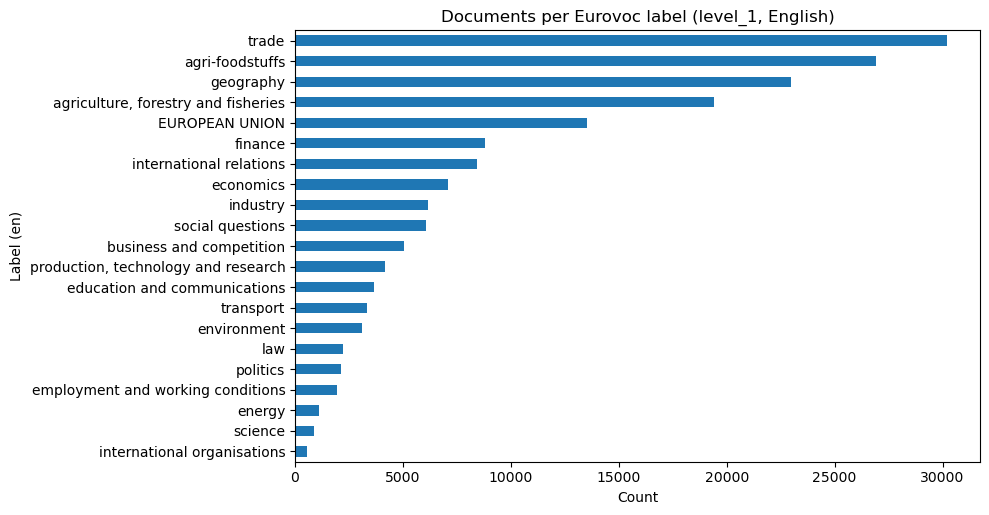

In [5]:
label_counts = exploded["labels_en"].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(label_counts) * 0.25)))
label_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Count")
ax.set_ylabel("Label (en)")
ax.set_title("Documents per Eurovoc label (level_1, English)")
plt.tight_layout()
plt.show()

**3)** Parse `celex_id`: 1 char sector, 4-digit year, letter(s) type until digits, then document code (string). Optional suffix `R(<digits>)` marks a revision; `is_revision` and `revision_number` capture that.

In [6]:
import re

# Optional R(<digits>) after document number = revision indicator (CELEX)
CELEX_RE = re.compile(r"^(.)(\d{4})([A-Za-z]+)(\d+)(?:R\((\d+)\))?$")


def parse_celex(s):
    if not isinstance(s, str) or not s:
        return (pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, False)
    m = CELEX_RE.match(s)
    if not m:
        return (pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, False)
    sector, year, celex_type, doc_code, rev = m.groups()
    is_rev = rev is not None
    rev_out = rev if is_rev else pd.NA
    return sector, year, celex_type, doc_code, rev_out, is_rev


parsed = df["celex_id"].apply(parse_celex)
df["sector"] = [p[0] for p in parsed]
df["year"] = [p[1] for p in parsed]
df["celex_type"] = [p[2] for p in parsed]
df["document_code"] = [p[3] for p in parsed]
df["revision_number"] = [p[4] for p in parsed]
df["is_revision"] = [p[5] for p in parsed]

matched = df["celex_id"].astype(str).str.match(CELEX_RE).sum()
print(f"Parsed {matched} / {len(df)} celex_id values")
print(f"Documents with revision suffix R(...): {df['is_revision'].sum()}")
df[[
    "celex_id",
    "sector",
    "year",
    "celex_type",
    "document_code",
    "is_revision",
    "revision_number",
]].head(10)

Parsed 55000 / 55000 celex_id values
Documents with revision suffix R(...): 0


,celex_id,sector,year,celex_type,document_code,is_revision,revision_number
0,32006D0213,3,2006,D,0213,False,<NA>
1,32003R1330,3,2003,R,1330,False,<NA>
2,32003R1786,3,2003,R,1786,False,<NA>
3,31985R2590,3,1985,R,2590,False,<NA>
4,31993R1103,3,1993,R,1103,False,<NA>
5,32004R1038,3,2004,R,1038,False,<NA>
6,31999D0272,3,1999,D,0272,False,<NA>
7,31992D0207,3,1992,D,0207,False,<NA>
8,32003R1012,3,2003,R,1012,False,<NA>
9,31993R1663,3,1993,R,1663,False,<NA>


**4)** Bar charts: `value_counts` for each parsed column (each document counts once per dimension), including `is_revision` and revision numbers where present.

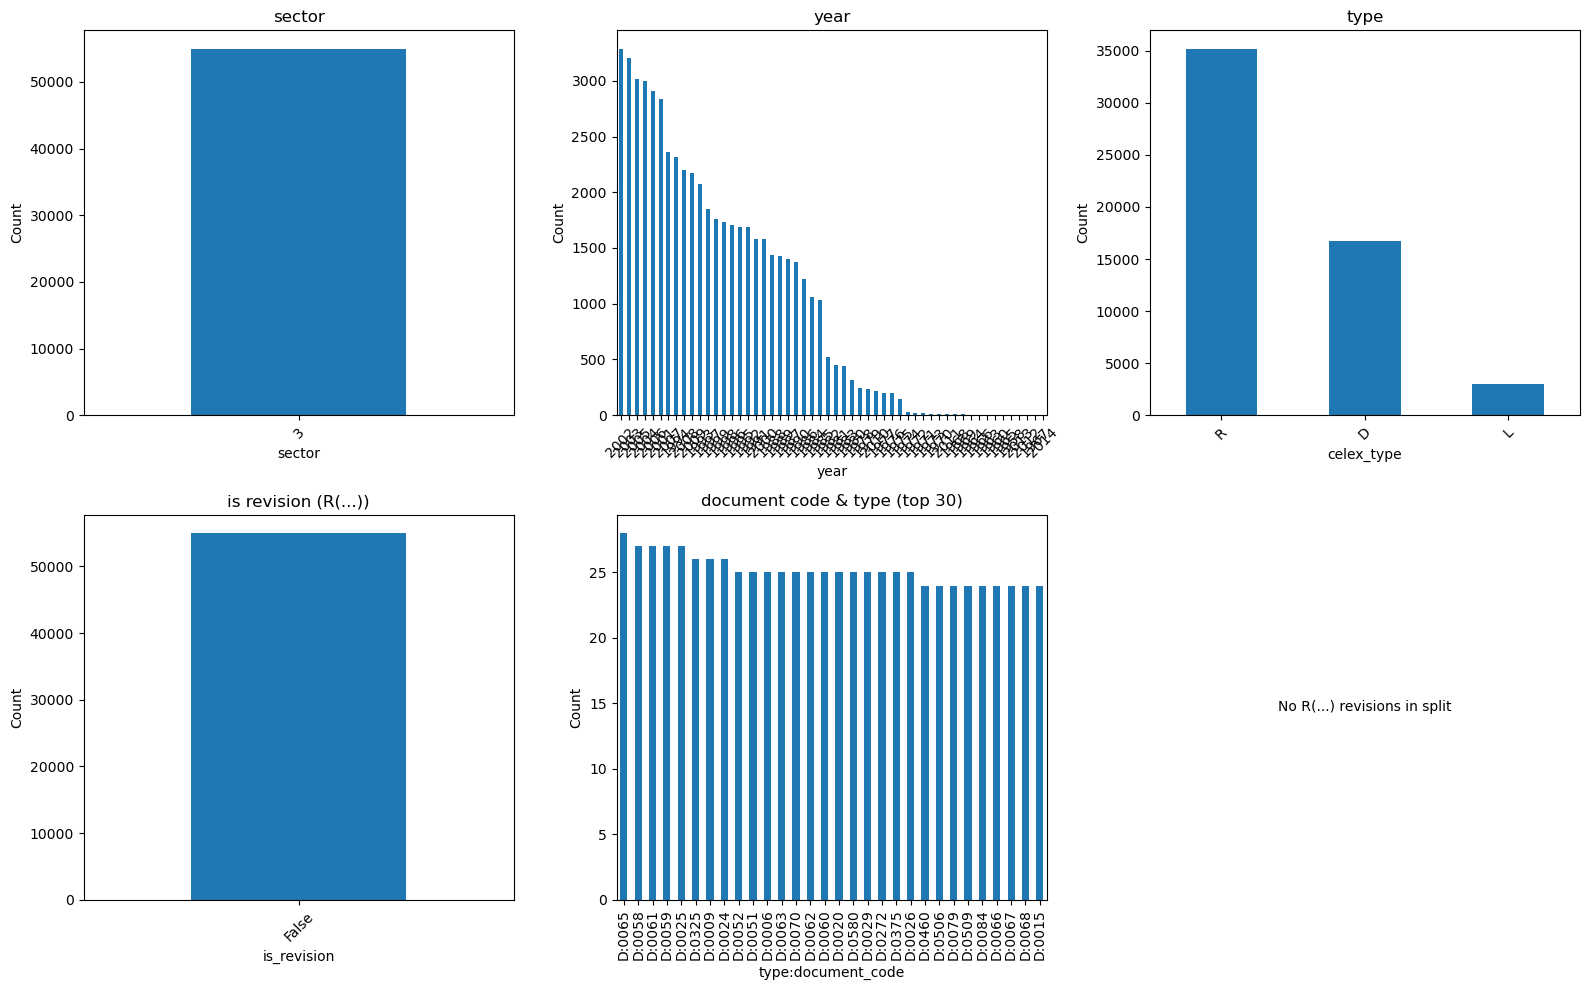

In [7]:
specs = [
    ("sector", "sector"),
    ("year", "year"),
    ("celex_type", "type"),
    # document_code is handled specially below
    ("is_revision", "is revision (R(...))"),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Plot standard columns
for ax, (col, title) in zip(axes[: len(specs)], specs):
    vc = df[col].value_counts()
    vc.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xlabel(col)

# Plot document_code grouped by type and document_code
doc_code_ax = axes[len(specs)]
type_doc_grp = df.groupby(["celex_type", "document_code"]).size().reset_index(name="count")
# Sort by most common combinations
top = type_doc_grp.sort_values("count", ascending=False).head(30)
bar_labels = top["celex_type"] + ":" + top["document_code"]
doc_code_bar = top.set_index(bar_labels)["count"]
doc_code_bar.plot(kind="bar", ax=doc_code_ax, rot=90)
doc_code_ax.set_title("document code & type (top 30)")
doc_code_ax.set_ylabel("Count")
doc_code_ax.set_xlabel("type:document_code")

# revision_number for revision docs
rev_vc = df.loc[df["is_revision"], "revision_number"].value_counts()
rev_ax = axes[len(specs) + 1]
if len(rev_vc):
    rev_vc.plot(kind="bar", ax=rev_ax, rot=45)
    rev_ax.set_title("revision_number (revisions only)")
    rev_ax.set_ylabel("Count")
    rev_ax.set_xlabel("revision_number")
else:
    rev_ax.text(0.5, 0.5, "No R(...) revisions in split", ha="center", va="center")
    rev_ax.set_axis_off()

plt.tight_layout()
plt.show()

**5)** Top repeated instruments by `(celex_type, document_code)`, then every **D-0065** row (Decision, document code 65) with **full `text`** for each document.

In [8]:
pair_counts = (
    df.groupby(["celex_type", "document_code"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .rename("count")
)
print("Top (celex_type, document_code) by row count:")
print(pair_counts.head(40).to_string())
print()

doc_num = pd.to_numeric(df["document_code"], errors="coerce")
mask_d_0065 = (df["celex_type"] == "D") & (doc_num == 65)
meta_cols = [
    "celex_id",
    "sector",
    "year",
    "celex_type",
    "document_code",
    "is_revision",
    "revision_number",
]
subset = df.loc[mask_d_0065].sort_values(["year", "celex_id"])
print(f"D-0065 (type D, document code 65): {len(subset)} rows")
print(subset[meta_cols].to_string())
print()

sep = "\n" + "=" * 80 + "\n"
for i, (_, row) in enumerate(subset.iterrows(), 1):
    print(f"{sep}### Document {i} / {len(subset)} — celex_id={row['celex_id']}{sep}")
    for c in meta_cols:
        print(f"{c}: {row[c]}")
    print(f"{sep}TEXT{sep}")
    print(row["text"])

Top (celex_type, document_code) by row count:
celex_type  document_code
D           0065             28
            0058             27
            0061             27
            0059             27
            0025             27
            0325             26
            0009             26
            0024             26
            0052             25
            0051             25
            0006             25
            0063             25
            0070             25
            0062             25
            0060             25
            0020             25
            0580             25
            0029             25
            0272             25
            0375             25
            0026             25
            0460             24
            0506             24
            0079             24
            0509             24
            0084             24
            0066             24
            0067             24
            0068             24


In [9]:
celex_lengths = df['celex_id'].astype(str).map(len)
print("Unique CELEX ID lengths:", celex_lengths.unique())
print("All CELEX IDs have the same length?", celex_lengths.nunique() == 1)

Unique CELEX ID lengths: [10]
All CELEX IDs have the same length? True


In [10]:
"""
TF-IDF + cosine duplicate removal: cosine > 0.8 => same duplicate group (union–find).
Per group, keep the document with the latest year (tie-break: smaller row index).

Creates:
  df_all — full corpus + dup_group_id, _orig_row_id, is_dedup_representative, dup_group_size
  df_dedup, df — deduplicated (alias)

At the end of this cell: prints one kept document vs all dropped duplicates in that group (visual QC).
Adjust SHOW_DUP_GROUP_ID / TEXT_MAX_CHARS below that block if needed.

Requires scikit-learn (e.g. conda env `Data`).
"""
import numpy as np
from collections import defaultdict
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

SIM_THRESHOLD = 0.9
BATCH_SIZE = 384

df_all = df.copy().reset_index(drop=True)
n_before = len(df_all)
texts = df_all["text"].fillna("").astype(str).str.lower()

vectorizer = TfidfVectorizer(lowercase=False)
X = vectorizer.fit_transform(texts)
X = normalize(X, norm="l2", axis=1)
if sparse.isspmatrix_csr(X):
    X.sort_indices()
else:
    X = X.tocsr()
    X.sort_indices()

year_int = pd.to_numeric(df_all["year"], errors="coerce").fillna(-1).astype(np.int64).to_numpy()

n = X.shape[0]
parent = np.arange(n, dtype=np.int64)
rank = np.zeros(n, dtype=np.int8)

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return
    if rank[ra] < rank[rb]:
        parent[ra] = rb
    elif rank[ra] > rank[rb]:
        parent[rb] = ra
    else:
        parent[rb] = ra
        rank[ra] += 1

pair_count = 0
for i0 in tqdm(range(0, n, BATCH_SIZE), desc="Pairwise cosine (batches)", unit="batch"):
    i1 = min(i0 + BATCH_SIZE, n)
    block = X[i0:i1] @ X.T
    if sparse.issparse(block):
        block = block.toarray()
    else:
        block = np.asarray(block)
    for local_i, gi in enumerate(range(i0, i1)):
        row = block[local_i, gi + 1 :]
        js = np.nonzero(row > SIM_THRESHOLD)[0] + (gi + 1)
        for j in js:
            union(gi, int(j))
        pair_count += int(js.size)

representative = np.fromiter((find(i) for i in range(n)), dtype=np.int64, count=n)
comp_members = defaultdict(list)
for i in range(n):
    comp_members[representative[i]].append(i)

n_dup_groups = sum(1 for ms in comp_members.values() if len(ms) > 1)

keeper_by_root = {}
for ms in comp_members.values():
    root = representative[ms[0]]
    keeper_by_root[root] = max(ms, key=lambda i: (year_int[i], -i))

keep_idx = list(keeper_by_root.values())
keep_mask = np.zeros(n, dtype=bool)
keep_mask[np.array(keep_idx, dtype=np.int64)] = True

_, dup_group_id = np.unique(representative, return_inverse=True)

df_all["_orig_row_id"] = np.arange(n_before, dtype=np.int64)
df_all["dup_group_id"] = dup_group_id.astype(np.int64)
df_all["is_dedup_representative"] = keep_mask
df_all["dedup_representative_orig_row_id"] = np.array(
    [keeper_by_root[representative[i]] for i in range(n)], dtype=np.int64
)
df_all["dup_group_size"] = df_all.groupby("dup_group_id")["dup_group_id"].transform("size")

df_dedup = df_all.loc[keep_mask].copy().reset_index(drop=True)
df = df_dedup

n_after = len(df_dedup)
n_dropped = n_before - n_after

print(f"Documents before deduplication: {n_before}")
print(f"Documents after deduplication:  {n_after}")
print(f"Duplicate groups (size > 1):    {n_dup_groups}")
print(f"Documents dropped:              {n_dropped}")
print(f"Pairs with cosine > {SIM_THRESHOLD}: {pair_count}")

# --- Visual QC: kept vs all dropped duplicates in one cluster ---
SHOW_DUP_GROUP_ID = None  # set to an int dup_group_id to inspect a specific group; None = first multi-doc group
TEXT_MAX_CHARS = None  # e.g. 8000 to truncate; None = full text

def _print_doc_block(title, row):
    print("=" * 72)
    print(title)
    print("=" * 72)
    print(
        f"celex_id: {row['celex_id']!r}  year: {row['year']!r}  "
        f"_orig_row_id: {row['_orig_row_id']}  "
        f"is_dedup_representative: {row['is_dedup_representative']}"
    )
    txt = "" if pd.isna(row.get("text")) else str(row["text"])
    if TEXT_MAX_CHARS is not None and len(txt) > TEXT_MAX_CHARS:
        print(f"\nTEXT ({len(txt)} chars, first {TEXT_MAX_CHARS} shown):\n")
        print(txt[:TEXT_MAX_CHARS])
        print("\n[... truncated; set TEXT_MAX_CHARS = None for full text ...]\n")
    else:
        print(f"\nTEXT ({len(txt)} chars):\n")
        print(txt)
    print()

print("\n--- Comparison: kept document vs dropped duplicates (same dup_group_id) ---\n")
candidates = df_all.loc[df_all["dup_group_size"] > 1, "dup_group_id"].drop_duplicates()
if candidates.empty:
    print("No duplicate groups (dup_group_size > 1). Nothing to compare.")
else:
    if SHOW_DUP_GROUP_ID is not None:
        g = int(SHOW_DUP_GROUP_ID)
        if g not in df_all["dup_group_id"].values:
            raise ValueError(f"dup_group_id {g} not found in df_all")
    else:
        g = int(candidates.iloc[0])

    grp = df_all[df_all["dup_group_id"] == g].sort_values(
        ["is_dedup_representative", "year"], ascending=[False, False]
    )
    kept_row = grp.loc[grp["is_dedup_representative"]].iloc[0]
    dropped_rows = grp.loc[~grp["is_dedup_representative"]]

    print(f"dup_group_id = {g}  |  documents in cluster: {len(grp)}  |  dropped: {len(dropped_rows)}")
    print()

    _print_doc_block("KEPT (newest-year representative)", kept_row)
    print(f"--- Dropped duplicates ({len(dropped_rows)}) ---\n")
    for idx, (_, r) in enumerate(dropped_rows.iterrows(), start=1):
        _print_doc_block(f"DROPPED duplicate #{idx}", r)


Pairwise cosine (batches):   0%|          | 0/144 [00:00<?, ?batch/s]

Documents before deduplication: 55000
Documents after deduplication:  33826
Duplicate groups (size > 1):    4402
Documents dropped:              21174
Pairs with cosine > 0.9: 706778

--- Comparison: kept document vs dropped duplicates (same dup_group_id) ---

dup_group_id = 0  |  documents in cluster: 3  |  dropped: 2

KEPT (newest-year representative)
celex_id: '32006D0213'  year: '2006'  _orig_row_id: 0  is_dedup_representative: True

TEXT (3233 chars):

COMMISSION DECISION
of 6 March 2006
establishing the classes of reaction-to-fire performance for certain construction products as regards wood flooring and solid wood panelling and cladding
(notified under document number C(2006) 655)
(Text with EEA relevance)
(2006/213/EC)
THE COMMISSION OF THE EUROPEAN COMMUNITIES,
Having regard to the Treaty establishing the European Community,
Having regard to Directive 89/106/EEC of 21 December 1988, on the approximation of laws, regulations and administrative provisions of the Member States re